[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EelcoHoogendoorn/numga/blob/rewrite/rewrite/examples/geometry/scenegraph/scenegraph.ipynb) [![Open in GitHub Codespaces](https://github.com/codespaces/badge.svg)](https://codespaces.new/EelcoHoogendoorn/numga?ref=rewrite)

# Scenegraph, Forward Kinematics & Camera Projection in PGA3D

In 3D graphics, transformation pipelines compose object poses, camera placement, and projection so that vertex arrays can be transformed in a single pass.

Projective Geometric Algebra (PGA) provides native geometric primitives: motors for rotations and translations without gimbal lock, and lines and planes for lenses and sensors. While motors handle rigid motion, scenegraphs also need **non-uniform scaling** to stretch canonical box primitives into robot bodies.

Using **extensors**, we can freely compose non-uniform scaling, joint motors, camera optics, and a pixel viewport into a **single compiled extensor** (`local_to_pixel`). We stay entirely within the GA-typed algebra—without dropping into coordinate types, while extensor application evaluates directly as a compiled linear map over the vertex array.

In [1]:
# Setup environment: clone repository and install dependencies if running in Colab
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    import os, shutil, subprocess
    os.chdir("/content")  # Always reset to /content
    repo_dir = Path("/content/numga_repo")
    if not repo_dir.exists():
        subprocess.run(["git", "clone", "--depth", "1", "-b", "rewrite", "https://github.com/EelcoHoogendoorn/numga.git", str(repo_dir)], check=True)
    else:
        subprocess.run(["git", "-C", str(repo_dir), "pull", "origin", "rewrite"], check=False)
    rewrite_dir = repo_dir / "rewrite"
    src_dir = rewrite_dir / "src"
    for p in [str(src_dir), str(rewrite_dir)]:
        if p not in sys.path:
            sys.path.insert(0, p)

# Ensure rewrite root is in sys.path when running locally:
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "examples" / "geometry" / "scenegraph").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        if str(candidate / "src") not in sys.path:
            sys.path.insert(0, str(candidate / "src"))
        break
    if (candidate / "rewrite" / "examples" / "geometry" / "scenegraph").is_dir():
        p = str(candidate / "rewrite")
        if not p in sys.path:
            sys.path.insert(0, p)
        if str(candidate / "rewrite" / "src") not in sys.path:
            sys.path.insert(0, str(candidate / "rewrite" / "src"))
        break

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from numga import NumpyContext, stack
from numga.algebras import PGA3D
from examples.animation import save_animation
from examples.geometry.scenegraph import render

# Bind 3D Projective Geometric Algebra PGA3D (signature 3, 0, 1):
ctx = NumpyContext(PGA3D)
mv = ctx.multivector

# Blade Subspaces:
Scalar = PGA3D.gatype.scalar()                 # Grade 0: scalar
Plane = PGA3D.gatype.vector()                  # Grade 1: plane
Line = PGA3D.gatype.bivector()                 # Grade 2: line
Point = PGA3D.gatype.antivector()              # Grade 3: point
Motor = PGA3D.gatype.rotor()                   # Motor: rotation and translation

# Extensors (linear maps between blade subspaces):
PointMap = PGA3D.gatype((Point, Point))        # Point <- Point
LineMap = PGA3D.gatype((Line, Line))           # Line <- Line

## 1. Canonical Geometry & Non-Uniform Scaling Extensors

Every body in the scenegraph is shaped from a canonical unit cube. Motors rotate and translate bodies, while **extensors** handle non-uniform scaling to stretch shapes into form.

In [3]:
# Canonical unit cube [-0.5, 0.5]^3 vertices in homogeneous coordinates:
unit_box = mv.antivector([
    [-0.5, -0.5, -0.5, 1.0],
    [ 0.5, -0.5, -0.5, 1.0],
    [ 0.5,  0.5, -0.5, 1.0],
    [-0.5,  0.5, -0.5, 1.0],
    [-0.5, -0.5,  0.5, 1.0],
    [ 0.5, -0.5,  0.5, 1.0],
    [ 0.5,  0.5,  0.5, 1.0],
    [-0.5,  0.5,  0.5, 1.0],
])  # [8] Point

# Non-uniform scaling extensor: Point <- Point along principal axes:
def make_anisotropic_scale(scale_x: float, scale_y: float, scale_z: float = 1.0):
    return ctx.extensor(PointMap, np.diag([scale_x, scale_y, scale_z, 1.0]))  # [] Point <- Point

scale_upper_arm = make_anisotropic_scale(0.24, 0.24, 1.2)                    # [] Point <- Point

## 2. Articulated Robot Arm Forward Kinematics

We assemble a multi-body robot arm using joint motors. Applying a motor to an extensor (`pose >> scale`) transforms the body from model space into world space.

In [4]:
# Motor generators:
def make_translator(dx: float, dy: float, dz: float):
    return (mv.xw * (dx * 0.5) + mv.yw * (dy * 0.5) + mv.zw * (dz * 0.5)).exp()  # [] Motor

def make_rotor_y(angle_rad: float):
    return (mv.zx * (angle_rad * 0.5)).exp()                                      # [] Motor

def make_rotor_z(angle_rad: float):
    return (mv.xy * (angle_rad * 0.5)).exp()                                      # [] Motor

# Assemble the 5-body articulated robot arm hierarchy:
# Applying a motor to an extensor (pose >> scale) transforms the output points into world space:
def make_robot_arm(
    theta_base: float = 0.35,
    theta_shoulder: float = -0.45,
    theta_elbow: float = 0.85,
    theta_wrist: float = -0.40,
):
    # Body 0: Base pedestal resting on floor z = 0
    scale_0 = make_anisotropic_scale(0.9, 0.9, 0.25)                              # [] Point <- Point
    pose_0 = make_translator(0.0, 0.0, 0.125)                                     # [] Motor
    body_0 = pose_0 >> scale_0                                                    # [] Point <- Point

    # Body 1: Turret rotating body (yawing around vertical z)
    pivot_turret = make_translator(0.0, 0.0, 0.25) * make_rotor_z(theta_base)     # [] Motor
    scale_1 = make_anisotropic_scale(0.5, 0.5, 0.35)                              # [] Point <- Point
    pose_1 = pivot_turret * make_translator(0.0, 0.0, 0.175)                     # [] Motor
    body_1 = pose_1 >> scale_1                                                    # [] Point <- Point

    # Body 2: Upper arm (pitching around local y)
    pivot_shoulder = pivot_turret * make_translator(0.0, 0.0, 0.35) * make_rotor_y(theta_shoulder) # [] Motor
    scale_2 = make_anisotropic_scale(0.24, 0.24, 1.2)                             # [] Point <- Point
    pose_2 = pivot_shoulder * make_translator(0.0, 0.0, 0.6)                      # [] Motor
    body_2 = pose_2 >> scale_2                                                    # [] Point <- Point

    # Body 3: Forearm (pitching around local y)
    pivot_elbow = pivot_shoulder * make_translator(0.0, 0.0, 1.2) * make_rotor_y(theta_elbow)     # [] Motor
    scale_3 = make_anisotropic_scale(0.18, 0.18, 1.0)                             # [] Point <- Point
    pose_3 = pivot_elbow * make_translator(0.0, 0.0, 0.5)                         # [] Motor
    body_3 = pose_3 >> scale_3                                                    # [] Point <- Point

    # Body 4: Gripper wrist (pitching around local y)
    pivot_wrist = pivot_elbow * make_translator(0.0, 0.0, 1.0) * make_rotor_y(theta_wrist)        # [] Motor
    scale_4 = make_anisotropic_scale(0.28, 0.14, 0.3)                             # [] Point <- Point
    pose_4 = pivot_wrist * make_translator(0.0, 0.0, 0.15)                        # [] Motor
    body_4 = pose_4 >> scale_4                                                    # [] Point <- Point

    # Stack all 5 body extensors into a single batched extensor:
    return stack([body_0, body_1, body_2, body_3, body_4])                        # [5] Point <- Point

bodies_to_world = make_robot_arm()                                                 # [5] Point <- Point

## 3. Compound Multi-Lens Camera Optics

Camera optics are modeled with extensors: thin-lens refraction, placing lenses at offsets along the optical axis, and sensor plane intersection. Composing these stages compiles the full camera into a single projection extensor.

In [5]:
# Camera pose: position at (0, -3.6, 1.3) pitched towards target (0, 0, 1.18):
cam_pos = make_translator(0.0, -3.6, 1.3)                                                     # [] Motor
pitch_angle = np.arctan2(1.18 - 1.3, 0.0 - -3.6)
cam_rot = (mv.yz * ((np.pi * 0.5 - pitch_angle) * 0.5)).exp()                                  # [] Motor
camera_pose = cam_pos * cam_rot                                                                # [] Motor

# Thin-lens extensor constructor at canonical optical origin (z = 0):
# Subspace symbol 'Line' acts as an input placeholder, compiling into an extensor Line <- Line:
def make_thin_lens(focal_length: float, center: Point = mv.zyx, plane: Plane = -mv.z):
    return Line - (center & (Line ^ plane)) / focal_length                                     # [] Line <- Line

# Front objective lens at origin:
focal_front, focal_rear = 1.0, 0.8
front_lens = make_thin_lens(focal_front)                                                       # [] Line <- Line

# Displace rear relay lens along the optical axis:
# Transform rays into the lens local frame (<<), refract them, and transform back (>>):
rear_gap = -0.3
rear_placement = make_translator(0.0, 0.0, rear_gap)                                          # [] Motor
rear_lens = rear_placement >> make_thin_lens(focal_rear)(rear_placement << Line)               # [] Line <- Line

# Sensor plane intersection extensor: Point <- Line
sensor_distance = 1.25
sensor_plane = mv.z + sensor_distance * mv.w                                                   # [] Plane
to_sensor = Line ^ sensor_plane                                                                # [] Point <- Line

# Entrance pupil aperture sample:
pupil_radius = 0.02
pupil = (mv.xw * pupil_radius).exp() >> mv.zyx                                                 # [] Point

# Ray constructor extensor (joins incoming scene point with pupil): Line <- Point
ray_constructor = Point & pupil                                                                # [] Line <- Point

# Intrinsic camera extensor (camera local frame to sensor plane: Point <- Point):
# Functional composition multiplies the underlying matrices together under the hood:
camera = to_sensor(rear_lens(front_lens(ray_constructor)))                                     # [] Point <- Point

## 4. Viewport Rasterization & Single Extensor Pipeline Collapse

By composing the camera pose, lens optics, and screen viewport, we obtain a world-to-pixel projection extensor. Composing this with forward kinematics collapses the entire pipeline for all five bodies into a single batched extensor (`local_to_pixel`).

In [6]:
# Viewport extensor (maps physical 1.6 x 1.2 sensor to 640 x 480 screen pixels):
width, height = 640, 480
sensor_width, sensor_height = 1.6, 1.2
scale_px = width / sensor_width  # 400 px/unit

# Translate optical center to (W/2, H/2) and reflect y (raster row v increases downward):
viewport = make_translator(width * 0.5, height * 0.5, 0.0) >> make_anisotropic_scale(scale_px, -scale_px, 1.0)  # [] Point <- Point

# Camera projection pipeline (world space to screen pixels: Point <- Point):
# 1. Pull world points into camera space:
world_to_cam = camera_pose << Point                                                           # [] Point <- Point

# 2. Compose camera pose, intrinsic lens optics, and viewport into world_to_pixel:
world_to_pixel = viewport(camera(world_to_cam))                                               # [] Point <- Point

# 3. Collapse kinematics and projection into a single batched extensor:
local_to_pixel = world_to_pixel(bodies_to_world)                                               # [5] Point <- Point

# 3D world body vertices (evaluated once for the 3D scene plot):
world_vertices = bodies_to_world[:, None](unit_box[None, :])                                   # [5, 8] Point

# 2D screen pixels (evaluated once via single collapsed extensor):
raw_pixels = local_to_pixel[:, None](unit_box[None, :])                                       # [5, 8] Point
projected_pixels = raw_pixels / (mv.w & raw_pixels)                                            # [5, 8] Point

## 5. Visualizing 3D World Scene & Photographed 2D Sensor View

Evaluating the pipeline produces both the 3D world scene showing the articulated robot and camera rig, and the photographed 2D view on the camera sensor chip.

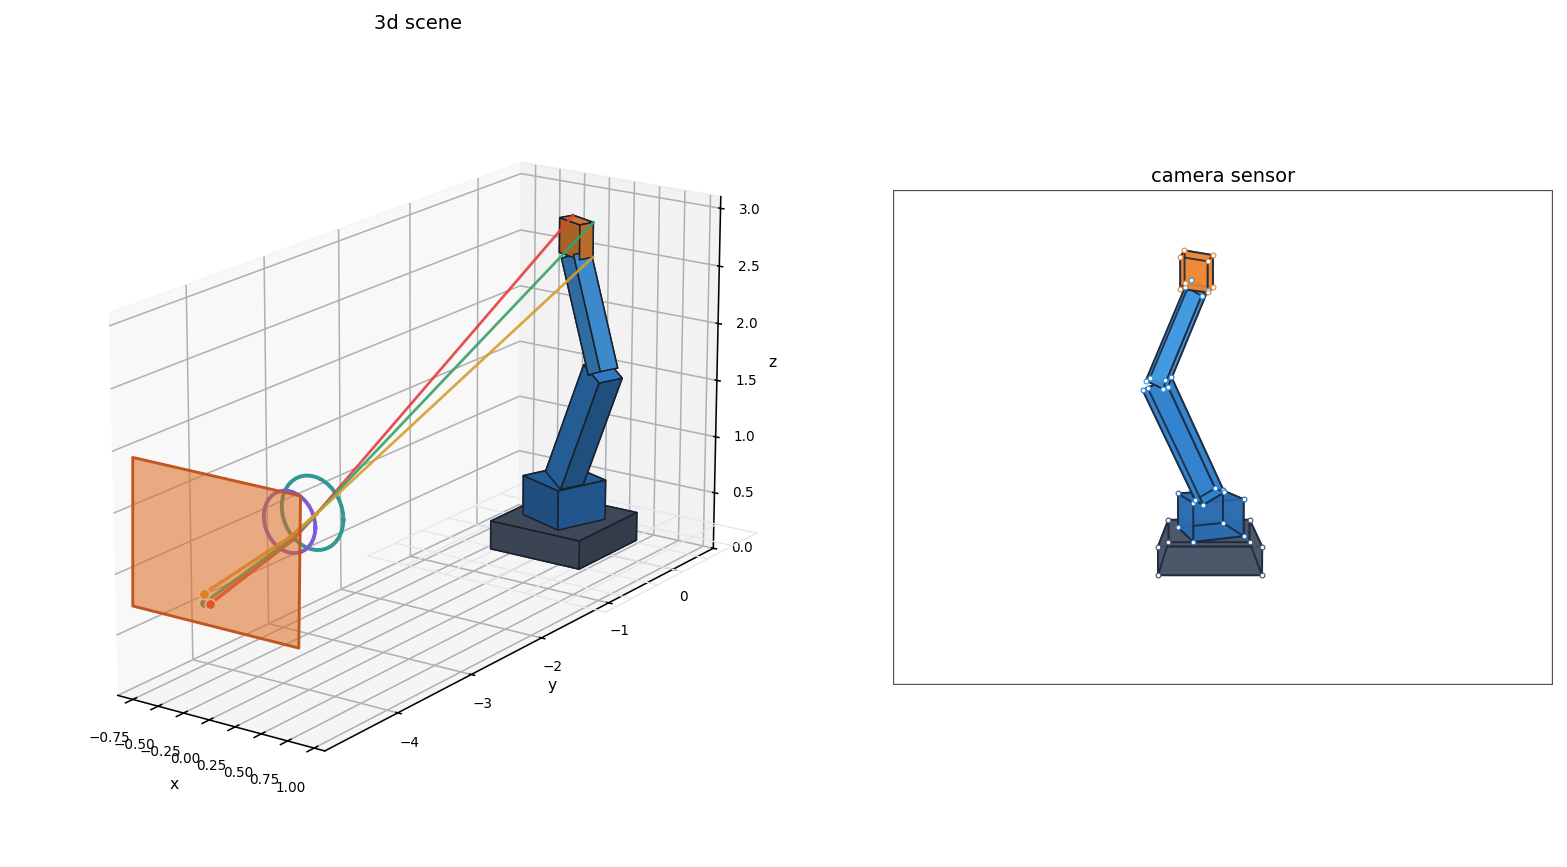

In [7]:
# Trace sample rays stage by stage: into the camera frame, joined with the pupil, refracted
# by each lens, and met with the rear lens plane and the sensor plane:
rear_plane = rear_placement >> -mv.z                                                           # [] Plane

def trace(scene_points):
    ray_mid = front_lens((camera_pose << scene_points) & pupil)                                # [n] Line
    rear_hit = ray_mid ^ rear_plane                                                            # [n] Point
    sensor_hit = rear_lens(ray_mid) ^ sensor_plane                                             # [n] Point
    return (
        scene_points,
        (camera_pose >> pupil).broadcast_to(scene_points.shape),
        camera_pose >> (rear_hit / (mv.w & rear_hit)),
        camera_pose >> (sensor_hit / (mv.w & sensor_hit)),
    )

# Render combined figure (3D scene + 2D sensor photograph), with rays from three gripper corners:
rays = trace(world_vertices[-1, [7, 6, 2]])
fig = render.draw_scenegraph(world_vertices, projected_pixels, camera_pose, rays)
plt.show()

## 6. Forward Kinematics Animation & Dynamic Sensor Capture

We animate the robot arm along a trajectory, separating the motion into modular streams for kinematics, 3D world geometry, and 2D camera projection.

Saved /Users/eelco/development/hobby/numga/rewrite/plots/scenegraph_02.gif


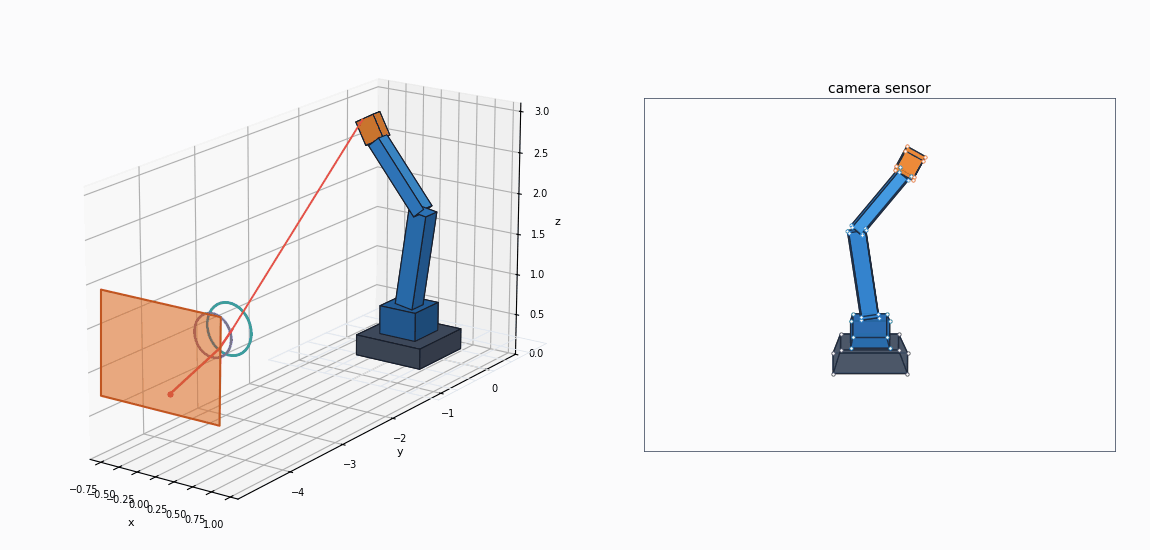

In [8]:
# 1. Kinematics generator: yields joint configurations as batched extensors (touches zero geometry):
def generate_robot_trajectory(num_frames: int = 36):
    t_vals = np.linspace(0, 2 * np.pi, num_frames, endpoint=False)
    for t in t_vals:
        angles = (
            0.45 * np.sin(t),
            -0.40 + 0.25 * np.cos(t),
            0.85 + 0.35 * np.sin(t),
            -0.45 + 0.25 * np.cos(2 * t),
        )
        yield make_robot_arm(*angles)                                  # [5] Point <- Point

# Generate trajectory of kinematic body extensors:
trajectory = list(generate_robot_trajectory(num_frames=36))

# 2. Pure 2D camera projection stream: collapses kinematics to pixels and evaluates geometry ONCE:
def generate_projected_frames(trajectory):
    for frame_bodies in trajectory:
        local_to_pixel = world_to_pixel(frame_bodies)                  # [5] Point <- Point
        raw_pixels = local_to_pixel[:, None](unit_box[None, :])        # [5, 8] Point
        yield raw_pixels / (mv.w & raw_pixels)                         # [5, 8] Point

# 3. 3D world geometry stream: evaluates geometry ONCE for the 3D scene visualization:
def generate_world_frames(trajectory):
    for frame_bodies in trajectory:
        yield frame_bodies[:, None](unit_box[None, :])                 # [5, 8] Point

# Stream both generators synchronized into the 2-panel animator, with the ray from the gripper tip:
frames = render.animate_scenegraph(
    (world, pixels, camera_pose, trace(world[-1, 7:8]))
    for world, pixels in zip(generate_world_frames(trajectory), generate_projected_frames(trajectory))
)
gif = save_animation(frames, "scenegraph", 60)
display(Image(filename=str(gif)))

## 7. Summary

1. **Non-uniform scaling**: Extensors stretch canonical unit box primitives into custom body shapes.
2. **Expressive kinematics**: Motors rotate and translate bodies natively without gimbal lock.
3. **Compound optics**: Lenses, sensor planes, and viewports compose directly as extensors.
4. **Pipeline collapse**: Composing forward kinematics with projection yields a single compiled extensor.
5. **Compiled Linear Execution**: Extensors evaluate directly as compiled linear maps over the vertex array, matching classical graphics performance while staying entirely within the GA-typed algebra.